In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from typing import Optional, Tuple
from tqdm import tqdm
from p_tqdm import p_map

#plt.style.use("seaborn-v0_8")
plt.rcParams.update({"font.size": 11, "figure.dpi": 200})

from simulation.make_dataset import make_dataset
from simulation.simulator import *
from constants import *
import matplotlib.ticker as ticker
from ml.profile_inversion import ProfileInversion, estimate_laws

/u/mgalexan/NPSurr/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Fixed values for plotting
d_val_m = 40e-9
k_rel = 1e-5
phys = PhysicsConstants(d_val_m= d_val_m, k_rel= k_rel)
params = SimulationParameters()
D_true = D_N_from_dim(phys)
P_true = P_N_from_dim(phys)
alpha = alpha_from_dim(phys)
A_true = (D_true * params.t_f) / (params.R_T ** 2)
G_true = (P_true * params.R_T) / D_true

# Make full-size datasets for different noise levels
noise_levels = [0.00, 0.02, 0.05, 0.2]
data_params = DatasetParameters(
    d_val_m= np.array([40e-9]),
    k_rel= np.array([k_rel]),
    save= False,
    noise_level= noise_levels[0]
)
datasets = []
for noise in noise_levels:
    data_params.noise_level = noise
    dataset = make_dataset(phys, params, data_params)
    dataset["CN"] = dataset["CN"][0,0, ::20, :]; dataset["CF"] = dataset["CF"][0,0, ::20, :]; dataset["CI"] = dataset["CI"][0,0, ::20, :]
    dataset["t_out"] = dataset["t_out"][::20]
    datasets.append(dataset)

d_val_m: 100%|██████████| 1/1 [00:00<00:00,  3.31it/s]


In [3]:
inv_params = InversionParameters()
inv = ProfileInversion(phys, params, inv_params)
A_grid = np.exp(np.linspace(np.log(inv_params.A_low), np.log(inv_params.A_high), 25))
G_grid = np.exp(np.linspace(np.log(inv_params.G_low), np.log(inv_params.G_high), 25))

In [4]:
def plot_loss_surface(
        L_surf: np.ndarray,
        A_grid: np.ndarray,
        Gamma_grid: np.ndarray,
        A_true: float,
        Gamma_true: float,
        A_est: float,
        Gamma_est: float,
        d_nm: int,
        fig: Optional[plt.Figure] = None,
        ax: Optional[plt.Axes] = None,
        norm: Optional[colors.Normalize] = None,
        show_colorbar: bool = True,
        title: Optional[str] = None,
    ) -> Tuple[plt.Figure, plt.Axes]:

        if fig is None or ax is None:
            fig, ax = plt.subplots(figsize=(6.5, 5.0))

        L_min_pos = L_surf[L_surf > 0].min() if np.any(L_surf > 0) else 1e-30
        L_plot = np.where(L_surf > 0, L_surf, L_min_pos)

        log_L = np.log10(L_plot).T
        x = np.log10(A_grid)
        y = np.log10(Gamma_grid)

        if norm is None:
            norm = colors.Normalize(vmin=log_L.min(), vmax=log_L.max())

        pcm = ax.pcolormesh(
            x,
            y,
            log_L,
            cmap="RdYlBu_r",
            shading="auto",
            norm=norm,
        )

        if show_colorbar:
            cb = fig.colorbar(pcm, ax=ax)
            cb.set_label(r"$\log_{10}\,\mathcal{L}(A,\,\Gamma)$")

        ax.contour(
            x,
            y,
            log_L,
            levels=20,
            colors="k",
            linewidths=0.5,
            alpha=0.35,
        )

        ax.scatter(
            np.log10(A_true), np.log10(Gamma_true),
            c="cyan", s=120, marker="*", zorder=6,
            edgecolors="k", linewidths=0.8,
            label="Data $(A, \Gamma)$",
        )
        ax.scatter(
            np.log10(A_est), np.log10(Gamma_est),
            c="red", s=80, marker="x", linewidths=2.5, zorder=6,
            label="Recovered",
        )

        if title is not None:
            ax.set_title(title)
        ax.legend(fontsize=9, loc="upper right")
        ax.grid(alpha=0.25)
        return fig, ax

In [5]:
def est_slope(x_vals, errors):
    x_vals = np.asarray(x_vals)
    errors = np.asarray(errors)

    mask = (errors > 0) & np.isfinite(errors)

    slope, intercept = np.polyfit(
        np.log(x_vals[mask]),
        np.log(errors[mask]),
        1
    )
    return slope

In [6]:
from p_tqdm import p_map

In [7]:
inv_results = p_map(inv.invert, datasets)
L_surfaces = p_map(lambda dataset: inv.loss_surface(dataset, A_grid, G_grid), datasets)

100%|██████████| 4/4 [10:50<00:00, 162.74s/it]


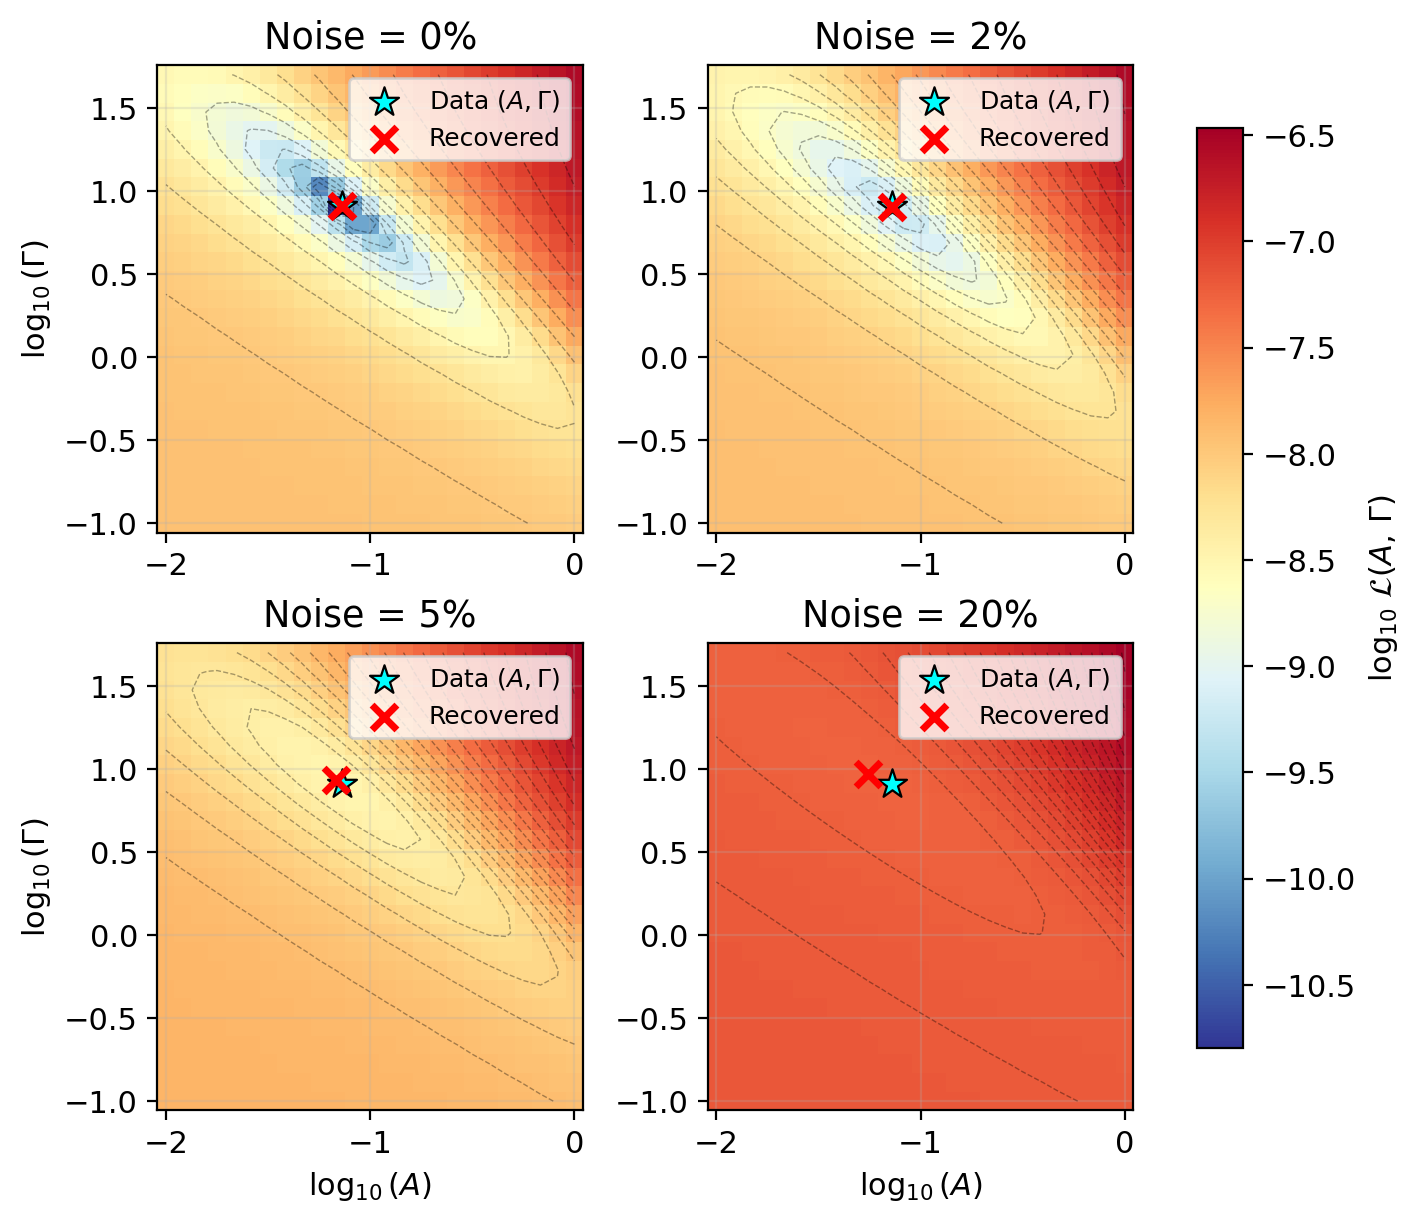

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(7, 6), constrained_layout= True)

log_L_values = []
for L_surf in L_surfaces:
    L_min_pos = L_surf[L_surf > 0].min() if np.any(L_surf > 0) else 1e-30
    L_plot = np.where(L_surf > 0, L_surf, L_min_pos)
    log_L_values.append(np.log10(L_plot))

common_norm = colors.Normalize(
    vmin=min(log_L.min() for log_L in log_L_values),
    vmax=max(log_L.max() for log_L in log_L_values),
)

for ax, noise, L_surf, inv_res in zip(axes.flat, noise_levels, L_surfaces, inv_results):
    plot_loss_surface(
        L_surf,
        A_grid,
        G_grid,
        A_true,
        G_true,
        inv_res["A_est"],
        inv_res["G_est"],
        int(d_val_m * 1e9),
        fig=fig,
        ax=ax,
        norm=common_norm,
        show_colorbar=False,
        title=f"Noise = {int(100 * noise)}%",
    )
for i in range(2):
    axes[1, i].set_xlabel(r"$\log_{10}(A)$")
    axes[i, 0].set_ylabel(r"$\log_{10}(\Gamma)$")
cbar = fig.colorbar(axes[0, 0].collections[0], ax=axes.ravel().tolist(), location="right", shrink=0.88)
cbar.set_label(r"$\log_{10}\,\mathcal{L}(A,\,\Gamma)$")
plt.show()

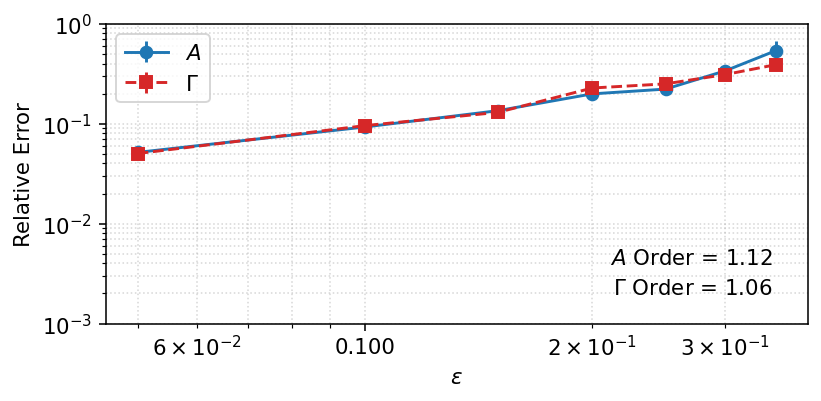

In [35]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.errorbar(noises, A_err_rels.mean(axis=1), A_err_rels.std(axis=1) / 10, marker='o', linestyle='-', color='tab:blue', label=r'$A$')
ax.errorbar(noises, G_err_rels.mean(axis=1), G_err_rels.std(axis=1) / 10, marker='s', linestyle='--', color='tab:red', label=r'$\Gamma$')
ax.set_xscale('log')
ax.set_yscale("log")
ax.set_ylim(1e-3, 1)
#ax.set_xticks(noises)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel(r'$\epsilon$')
ax.set_ylabel('Relative Error')
ax.grid(True, which='both', linestyle=':', alpha=0.5)
ax.legend()
slope_D = est_slope(noises, A_err_rels.mean(axis=1))
ax.annotate(rf"$A$ Order = {slope_A:.2f}", xy=(0.95, 0.25), xycoords="axes fraction", ha="right",  va="top")
ax.annotate(rf"$\Gamma$ Order = {slope_G:.2f}", xy=(0.95, 0.15), xycoords="axes fraction", ha="right",  va="top")
fig.tight_layout()

In [10]:
d_vals = np.array([20, 40, 60, 80]) * 1e-9
noisy_dataset_params = DatasetParameters(
    d_val_m=  d_vals,
    k_rel= np.array([1e-5]),
    save= False,
    noise_level= 0.05
)

def single_dataset_run(_):
    data_noisy = make_dataset(PhysicsConstants(), SimulationParameters(), noisy_dataset_params)
    data_obs = [{"r": data_noisy["r"], "t_out": data_noisy["t_out"][::20], "CN": data_noisy["CN"][i,0][::20]} for i in range(len(d_vals))]
    A_est_list, G_est_list, D_est_list, P_est_list = [], [], [], [] 
    for d_val, single_data in zip(d_vals, data_obs):
        inverter = ProfileInversion(PhysicsConstants(), SimulationParameters(), InversionParameters())
        inverter.phys.d_val_m = d_val
        res = inverter.invert(single_data)
        A_est_list.append(res["A_est"])
        G_est_list.append(res["G_est"])
        D_est_list.append(res["D_est"])
        P_est_list.append(res["P_est"])
    return {"A_est": A_est_list, "G_est": G_est_list, "D_est": D_est_list, "P_est": P_est_list}

results = p_map(single_dataset_run, range(100))

law_results = []

for res in results: 
    law_result = estimate_laws(d_vals, np.array(res["A_est"]), np.array(res["G_est"]), PhysicsConstants(), SimulationParameters())
    law_results.append(law_result)


100%|██████████| 100/100 [09:42<00:00,  5.82s/it] 


In [11]:
D_vals = []
P_vals = []
for d in d_vals:
    phys = PhysicsConstants(d_val_m=d)
    D_vals.append(D_N_from_dim(phys))
    P_vals.append(P_N_from_dim(phys))


In [12]:
def plot_diffusivity(
        diameters,
        D_true,
        results,
        law_results,
        phys: PhysicsConstants,
        fig = None,
        ax = None,
    ):
        """Data vs recovered D_N as a function of nanoparticle diameter."""
        if fig is None or ax is None:
            fig, ax = plt.subplots(figsize=(6, 4.5))

        a_D_mean = np.mean([law_result["a_D_mean"] for law_result in law_results])
        a_D_std = np.std([law_result["a_D_mean"] for law_result in law_results])
        D_est = np.mean([res["D_est"] for res in results], axis=0)
        D_std = np.std([res["D_est"] for res in results], axis=0)
        d = np.array(diameters)
        d_nm = d * 1e9
        D_SE = (phys.k_B * phys.T_K) / (
            3.0 * np.pi * phys.eta * d
        )
        D_law = D_SE * np.exp(-a_D_mean * d ** phys.m_exp)
        D_lower = D_SE * np.exp(-(a_D_mean + a_D_std) * d ** phys.m_exp)
        D_upper = D_SE * np.exp(-(a_D_mean - a_D_std) * d ** phys.m_exp)

        ax.fill_between(
            d_nm,
            D_lower,
            D_upper,
            color="orange",
            alpha=0.2,
        )
        ax.semilogy(d_nm, D_law, color="orange", linestyle="-",
                    linewidth=1.6, label=r"Estimated law")
        ax.semilogy(d_nm, D_true, "o-", color="blue",
                    label=r"Data $D_N$", markersize=5)
        ax.errorbar(d_nm, D_est, yerr=D_std, fmt="s--", color="lime",
                    label=r"Recovered $\hat{D}_N$", capsize=3, markersize=5)
        ax.set_xlabel("$d$ (nm)")
        ax.set_ylabel(r"$D_N$ (m$^2$ s$^{-1}$)")
        ax.set_title("Diffusivity Recovery")
        ax.legend()
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        fig.tight_layout()
        return fig, ax


def plot_permeability(
        diameters,
        P_true,
        results,
        law_results,
        phys: PhysicsConstants,
        fig = None,
        ax = None,
    ):
        """Data vs recovered P_N as a function of nanoparticle diameter."""
        if fig is None or ax is None:
            fig, ax = plt.subplots(figsize=(6, 4.5))

        a_P_mean = np.mean([law_result["a_P_mean"] for law_result in law_results])
        a_P_std = np.std([law_result["a_P_mean"] for law_result in law_results])
        P_est = np.mean([res["P_est"] for res in results], axis=0)
        P_std = np.std([res["P_est"] for res in results], axis=0)
        d = np.array(diameters)
        d_nm = d * 1e9
        P_law = phys.P0 * np.exp(-a_P_mean * d ** phys.n_exp)
        P_lower = phys.P0 * np.exp(-(a_P_mean + a_P_std) * d ** phys.n_exp)
        P_upper = phys.P0 * np.exp(-(a_P_mean - a_P_std) * d ** phys.n_exp)

        ax.fill_between(
            d_nm,
            P_lower,
            P_upper,
            color="orange",
            alpha=0.2,
        )
        ax.semilogy(d_nm, P_law, color="orange", linestyle="-",
                    linewidth=1.6, label=r"Estimated law")
        ax.semilogy(d_nm, P_true, "o-", color="blue",
                    label=r"Data $P_N$", markersize=5)
        ax.errorbar(d_nm, P_est, yerr=P_std, fmt="s--", color="lime",
                    label=r"Recovered $\hat{P}_N$", capsize=3, markersize=5)
        ax.set_xlabel("$d$ (nm)")
        ax.set_ylabel(r"$P_N$ (m s$^{-1}$)")
        ax.set_title("Permeability Recovery")
        ax.legend()
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        fig.tight_layout()
        return fig, ax

Text(-0.15, 1.05, 'b)')

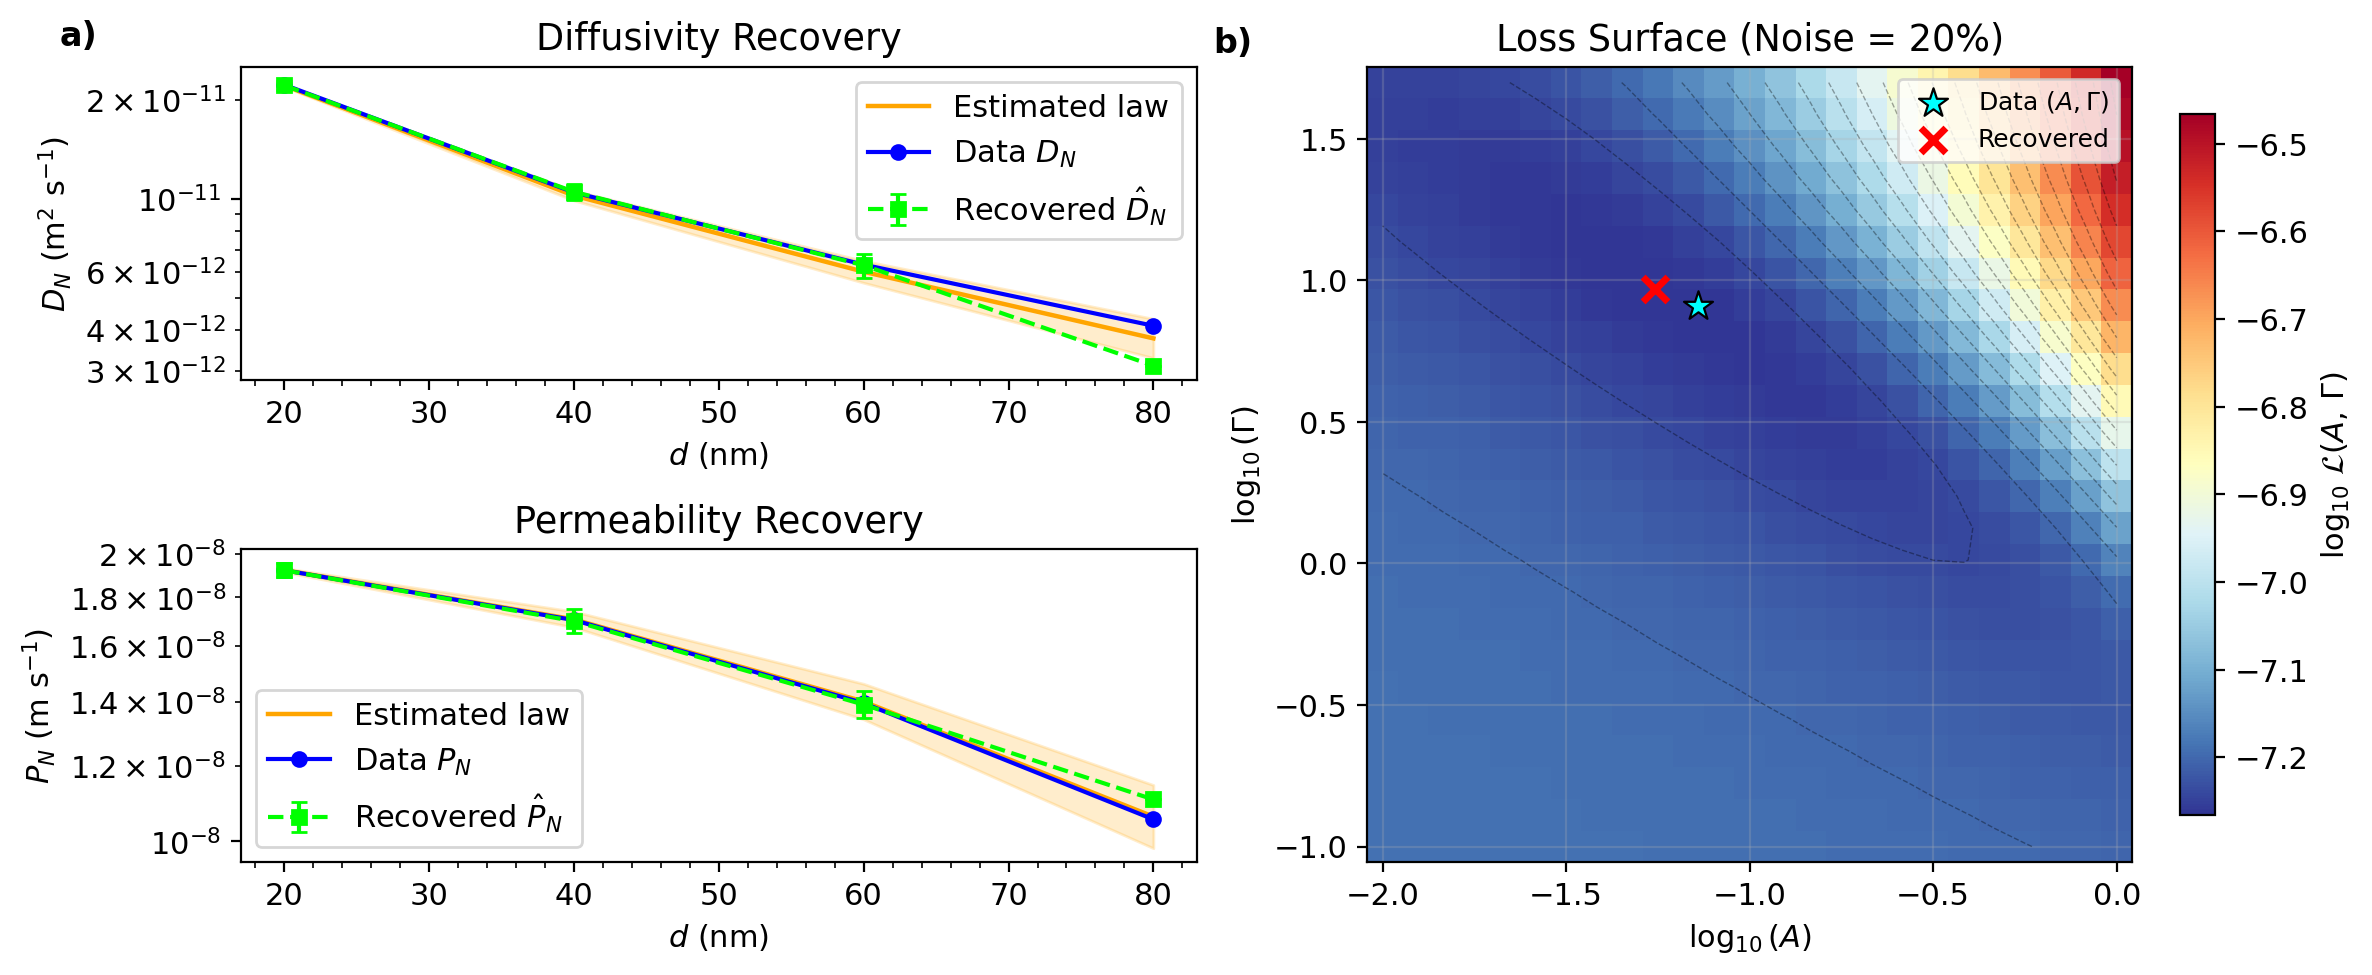

In [25]:
layout = [["A", "C"], ["B", "C"]]

fig, axes = plt.subplot_mosaic(layout, figsize=(12, 5))

plot_loss_surface(
    L_surfaces[3],
    A_grid,
    G_grid,
    A_true,
    G_true,
    inv_results[3]["A_est"],
    inv_results[3]["G_est"],
    int(d_val_m * 1e9),
    fig=fig,
    ax=axes["C"],
    norm=None,
    show_colorbar=False,
    title=f"Loss Surface (Noise = {int(100 * noise_levels[3])}%)",
)
for i in range(2):
    axes["C"].set_xlabel(r"$\log_{10}(A)$")
    axes["C"].set_ylabel(r"$\log_{10}(\Gamma)$")
cbar = fig.colorbar(axes["C"].collections[0], ax=axes["C"], location="right", shrink=0.88)
cbar.set_label(r"$\log_{10}\,\mathcal{L}(A,\,\Gamma)$")

plot_diffusivity(d_vals, D_vals, results, law_results, phys, fig=fig, ax=axes["A"])
plot_permeability(d_vals, P_vals, results, law_results, phys, fig=fig, ax=axes["B"])

axes["A"].text(-0.15, 1.15, "a)", transform=axes["A"].transAxes, fontsize=12, fontweight='bold', va='top', ha='right')
axes["C"].text(-0.15, 1.05, "b)", transform=axes["C"].transAxes, fontsize=12, fontweight='bold', va='top', ha='right')

#fig.tight_layout()

In [14]:

num_of_obs = [1, 2, 4, 8, 20, 50, 100]
strides = [200 // num for num in num_of_obs]

inv_params = InversionParameters()
inv = ProfileInversion(phys, params, inv_params)
data_params = DatasetParameters(
    d_val_m= np.array([40e-9]),
    k_rel= np.array([k_rel]),
    save= False,
    noise_level= 0.05
)

In [15]:
inv_num_results_overall = []
def single_inversion_run(_):
    data_num_obs = make_dataset(phys, params, data_params)
    data_num_obs["CN"] = data_num_obs["CN"][0,0]
    inv_num_results = []
    for stride in strides:
        data_stride = {"r": data_num_obs["r"], "t_out": data_num_obs["t_out"][::stride], "CN": data_num_obs["CN"][::stride, :]}
        inv_num_results.append(inv.invert(data_stride))
    return inv_num_results

inv_num_results_overall = p_map(single_inversion_run, range(100))

100%|██████████| 100/100 [21:52<00:00, 13.12s/it]  


In [16]:
A_est_obs = np.array([[res["A_est"] for res in inv_num_result] for inv_num_result in inv_num_results_overall])
G_est_obs = np.array([[res["G_est"] for res in inv_num_result] for inv_num_result in inv_num_results_overall])

In [17]:
A_rel_obs = np.abs(A_est_obs - A_true) / A_true
G_rel_obs = np.abs(G_est_obs - G_true) / G_true

A_rel_mean = A_rel_obs.mean(axis=0)
G_rel_mean = G_rel_obs.mean(axis=0)
A_rel_std = A_rel_obs.std(axis=0) / np.sqrt(100)
G_rel_std = G_rel_obs.std(axis=0) / np.sqrt(100)

In [18]:
A_slope_obs = est_slope(num_of_obs, A_rel_mean)
G_slope_obs = est_slope(num_of_obs, G_rel_mean)

In [19]:
inv_noise_levels = ProfileInversion(PhysicsConstants(), SimulationParameters(), InversionParameters())
noises = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35]
noise_level_results = []
for noise in noises:
    run_dataset_params = DatasetParameters(
        d_val_m=  np.array([40e-9]),
        k_rel= np.array([1e-5]),
        save= False,
        noise_level= noise
    )
    def single_dataset_run(_):
        data_noisy = make_dataset(PhysicsConstants(), SimulationParameters(), run_dataset_params)
        single_data = {"r": data_noisy["r"], "t_out": data_noisy["t_out"][::20], "CN": data_noisy["CN"][0,0][::20]}
        res = inv_noise_levels.invert(single_data)
        return {"A_est": res["A_est"], "G_est": res["G_est"], "D_est": res["D_est"], "P_est": res["P_est"]}
    
    noise_level_results.append(p_map(single_dataset_run, range(100)))

d_val_m: 100%|██████████| 1/1 [00:00<00:00,  3.26it/s]

d_val_m: 100%|██████████| 1/1 [00:00<00:00,  2.70it/s]

100%|██████████| 100/100 [06:35<00:00,  3.96s/it]


In [20]:
A_err_rels_noise = []
G_err_rels_noise = []
for res_list in noise_level_results:
    A_err_rels_noise.append([np.abs(res["A_est"] - A_true) / A_true for res in res_list])
    G_err_rels_noise.append([np.abs(res["G_est"] - G_true) / G_true for res in res_list])

In [21]:
A_err_rels_noise = np.array(A_err_rels_noise)
G_err_rels_noise = np.array(G_err_rels_noise)
slope_A_noise = est_slope(noises, A_err_rels_noise.mean(axis=1))
slope_G_noise = est_slope(noises, G_err_rels_noise.mean(axis=1))

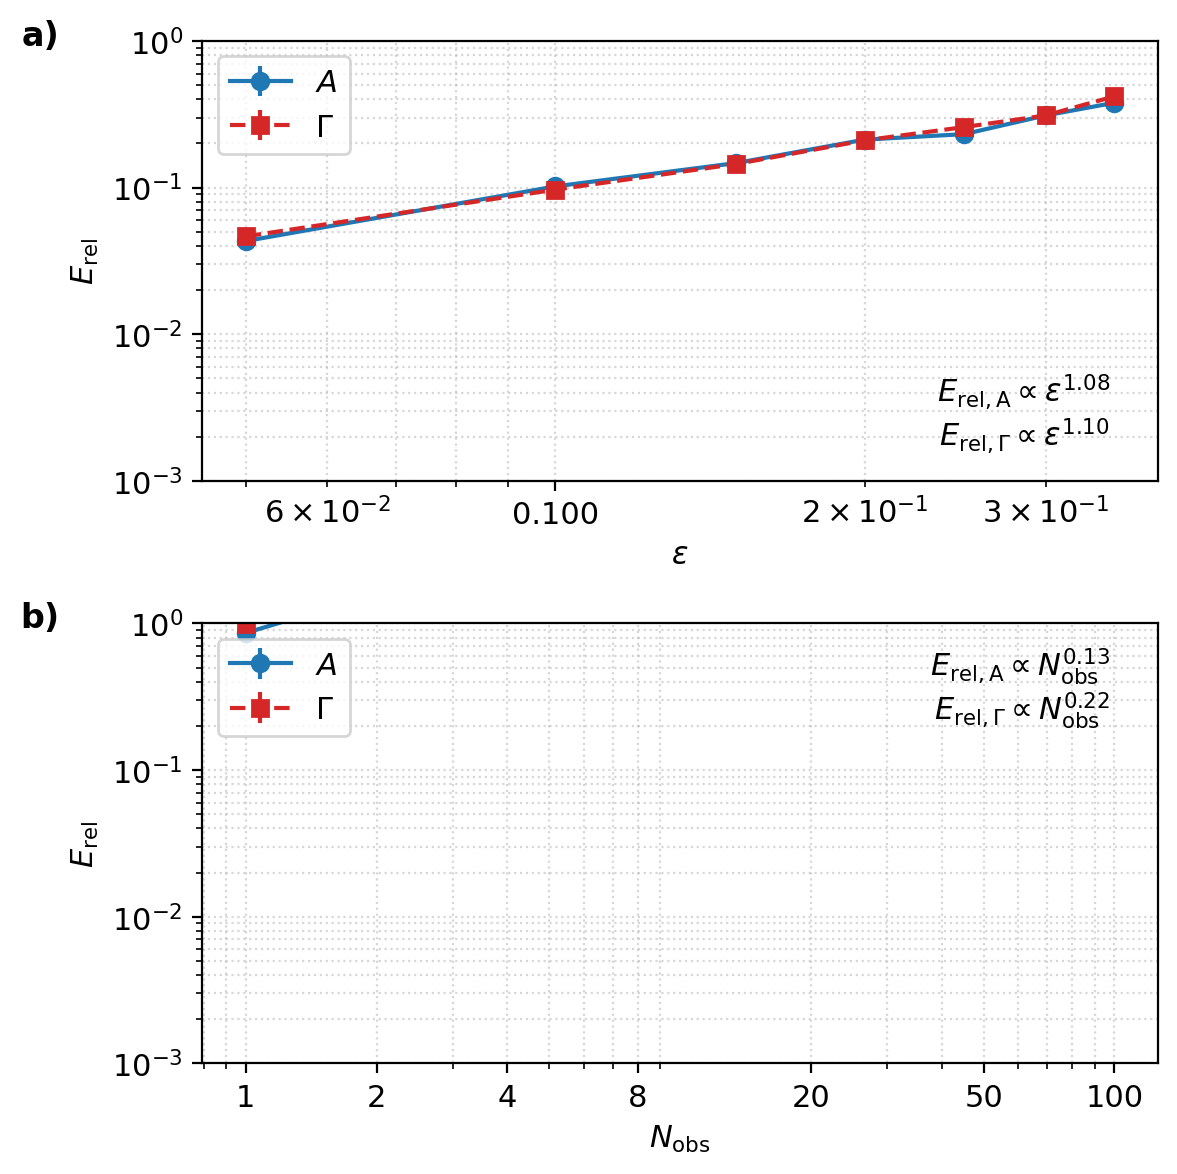

In [22]:
fig, ax = plt.subplots(2, 1, figsize=(6, 6))
ax[1].errorbar(num_of_obs, A_rel_mean, A_rel_std, marker='o', linestyle='-', color='tab:blue', label=r'$A$')
ax[1].errorbar(num_of_obs, G_rel_mean, G_rel_std, marker='s', linestyle='--', color='tab:red', label=r'$\Gamma$')
ax[1].set_xscale('log')
ax[1].set_yscale("log")
ax[1].set_ylim(1e-3, 1)
ax[1].get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax[1].set_xticks(num_of_obs)
ax[1].set_xlabel(r'$N_\mathrm{obs}$')
ax[1].set_ylabel('$E_\mathrm{rel}$')
ax[1].grid(True, which='both', linestyle=':', alpha=0.5)
ax[1].legend()
ax[1].annotate(rf"$E_{{\mathrm{{rel, A}}}} \propto N_\mathrm{{obs}}^{{{A_slope_obs:.2f}}}$", xy=(0.95, 0.95), xycoords="axes fraction", ha="right",  va="top")
ax[1].annotate(rf"$E_{{\mathrm{{rel, \Gamma}}}} \propto N_\mathrm{{obs}}^{{{G_slope_obs:.2f}}}$", xy=(0.95, 0.85), xycoords="axes fraction", ha="right",  va="top")
ax[1].text(-0.15, 1.05, "b)", transform=ax[1].transAxes, fontsize=12, fontweight='bold', va='top', ha='right')


ax[0].errorbar(noises, A_err_rels_noise.mean(axis=1), A_err_rels_noise.std(axis=1) / 10, marker='o', linestyle='-', color='tab:blue', label=r'$A$')
ax[0].errorbar(noises, G_err_rels_noise.mean(axis=1), G_err_rels_noise.std(axis=1) / 10, marker='s', linestyle='--', color='tab:red', label=r'$\Gamma$')
ax[0].set_xscale('log')
ax[0].set_yscale("log")
ax[0].set_ylim(1e-3, 1)
ax[0].get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax[0].set_xlabel(r'$\epsilon$')
ax[0].set_ylabel('$E_\mathrm{rel}$')
ax[0].grid(True, which='both', linestyle=':', alpha=0.5)
ax[0].legend()
ax[0].annotate(rf"$E_{{\mathrm{{rel, A}}}} \propto \epsilon^{{{slope_A_noise:.2f}}}$", xy=(0.95, 0.25), xycoords="axes fraction", ha="right",  va="top")
ax[0].annotate(rf"$E_{{\mathrm{{rel, \Gamma}}}} \propto \epsilon^{{{slope_G_noise:.2f}}}$", xy=(0.95, 0.15), xycoords="axes fraction", ha="right",  va="top")
ax[0].text(-0.15, 1.05, "a)", transform=ax[0].transAxes, fontsize=12, fontweight='bold', va='top', ha='right')

fig.tight_layout()